# Quality Control

## Preparation
First we prepare for further tasks by importing needed dependencies and by loading the data.

In [1]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.correlation import plot_corr
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
injection_molding_test_path = "InjectionMolding_Test.csv"
injection_molding_train_path = "InjectionMolding_Train.csv"

In [3]:
# Load data
training_data = pd.read_csv(injection_molding_train_path)
test_data = pd.read_csv(injection_molding_test_path)

In [4]:
training_data.columns

Index(['PowTotAct_Min', 'Inj1PosVolAct_Var', 'Inj1PrsAct_meanOfInjPhase',
       'Inj1HopTmpAct_1stPCscore', 'Inj1HtgEd3Act_1stPCscore',
       'ClpFceAct_1stPCscore', 'ClpPosAct_1stPCscore', 'OilTmp1Act_1stPCscore',
       'mass'],
      dtype='object')

## Data Oveview

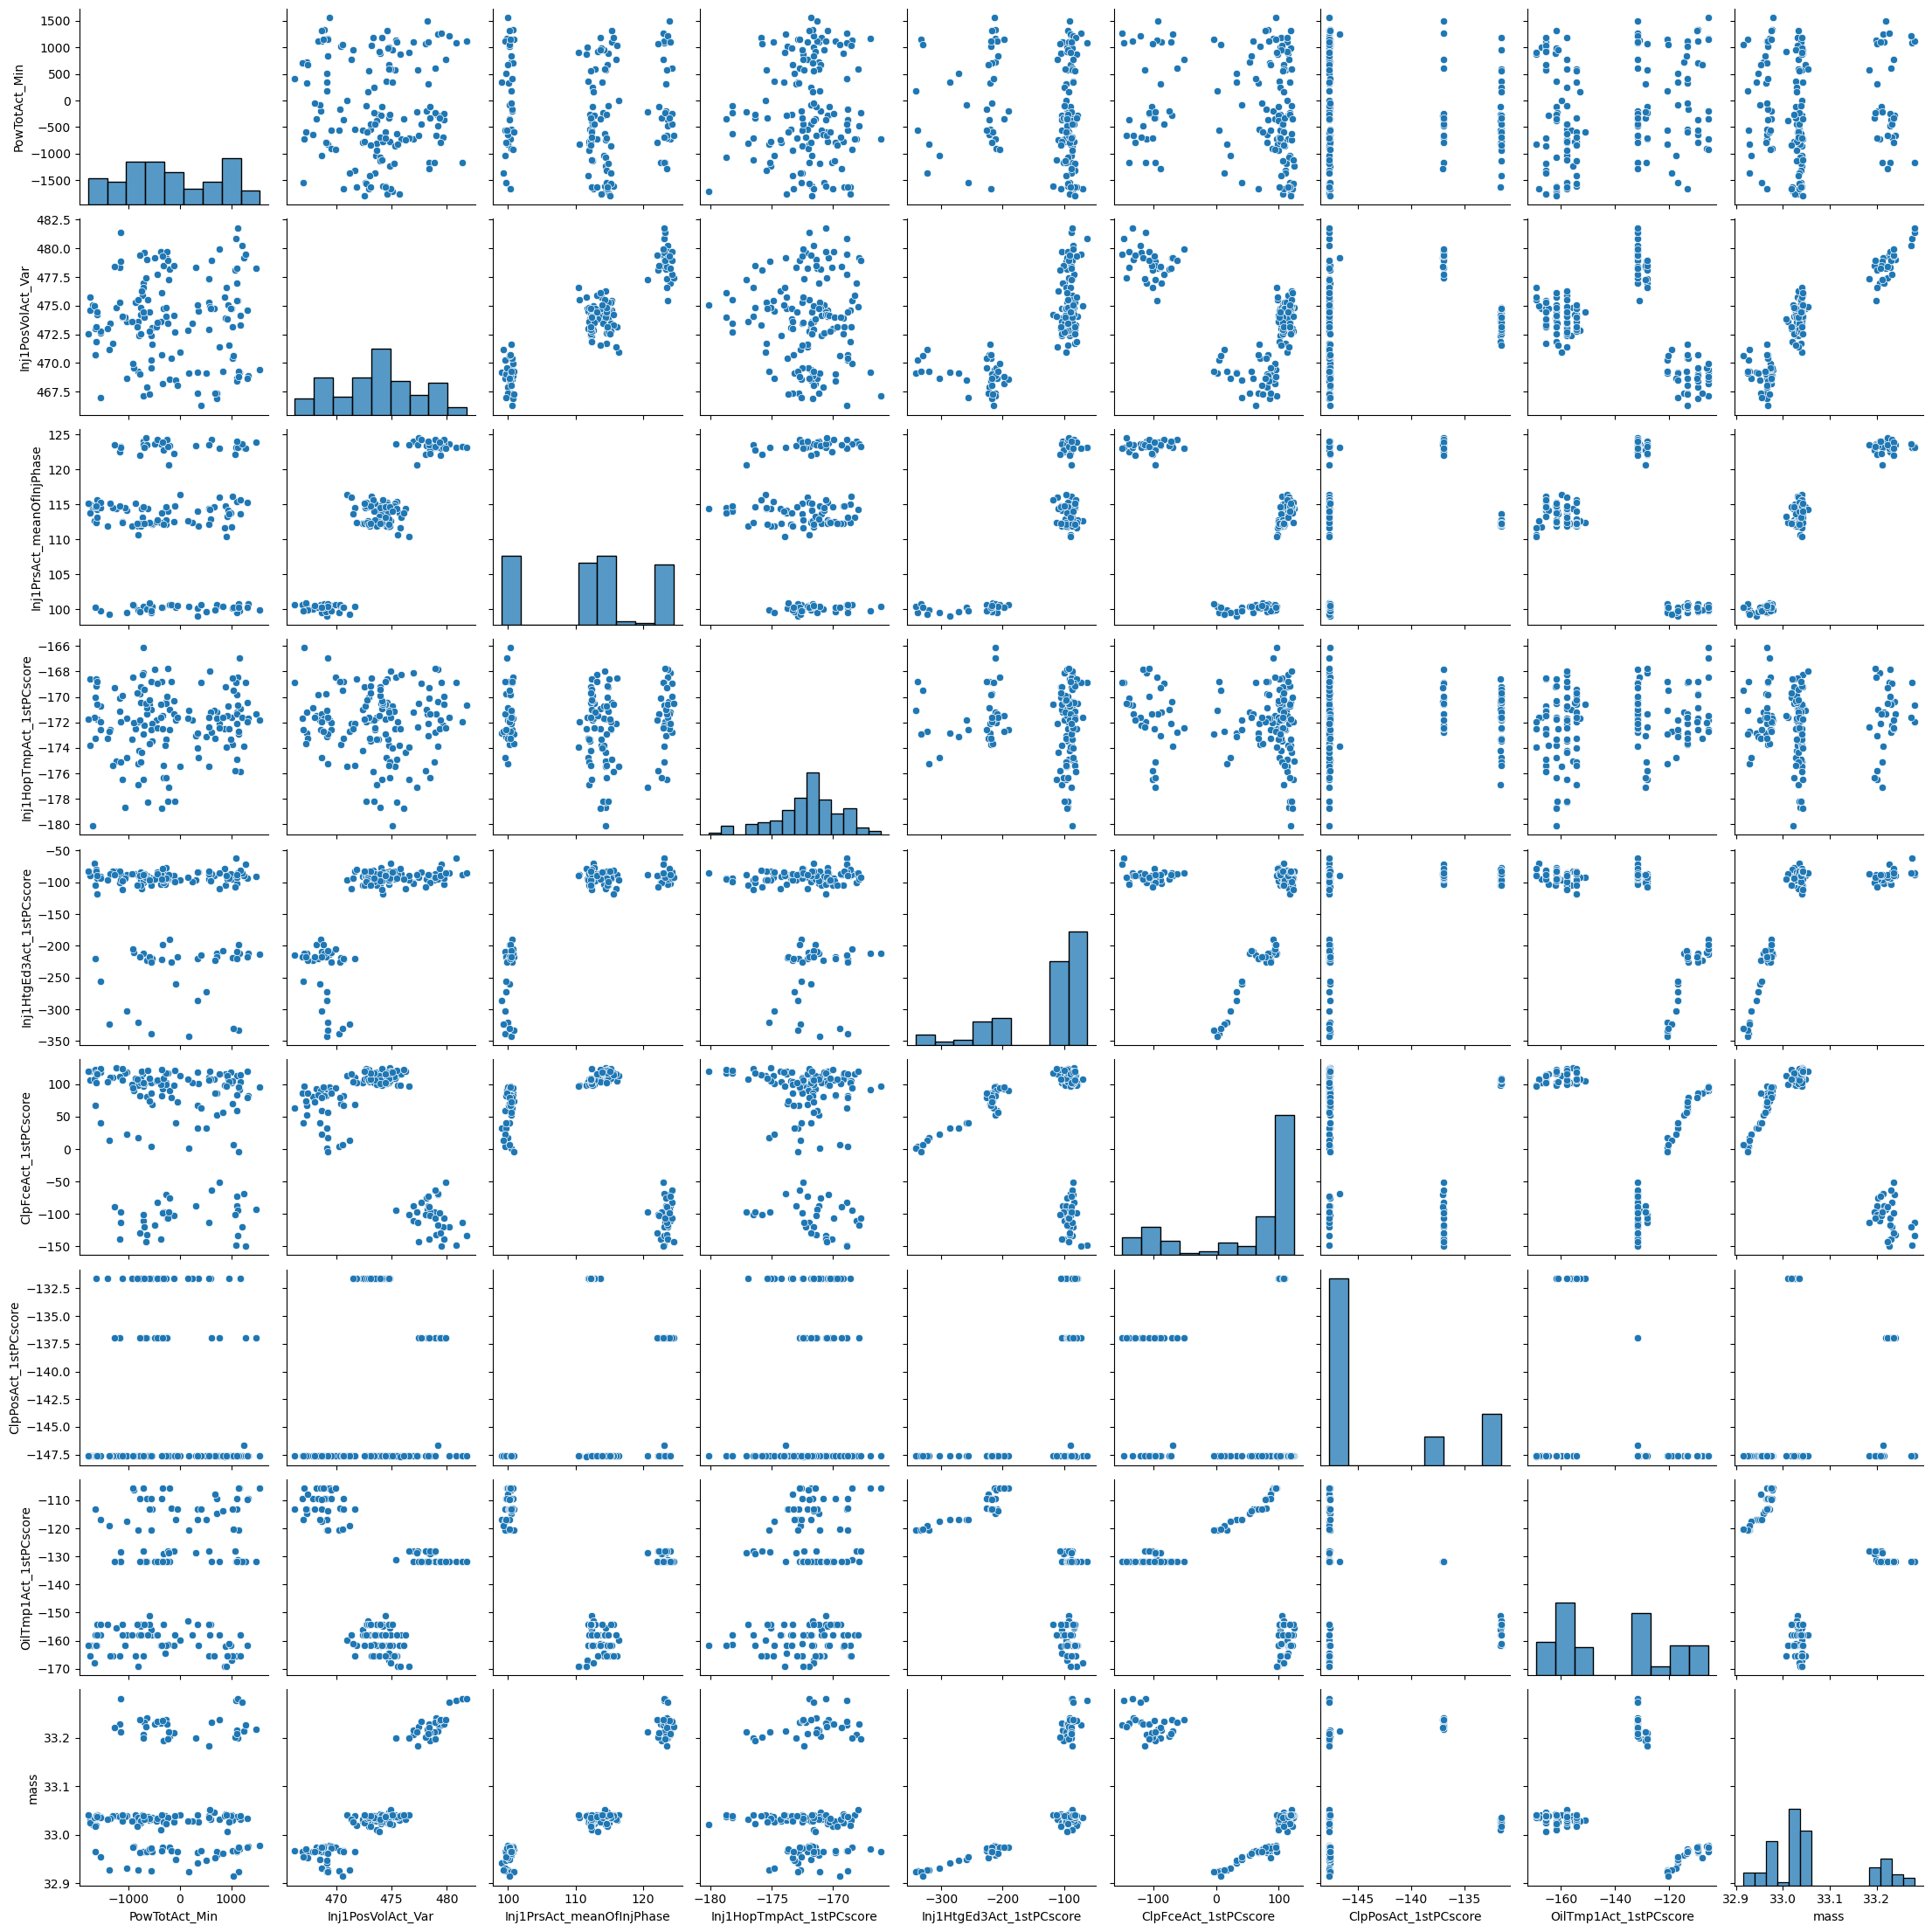

In [168]:
sb.pairplot(training_data)

In [218]:
training_data.describe()

,PowTotAct_Min,Inj1PosVolAct_Var,Inj1PrsAct_meanOfInjPhase,Inj1HopTmpAct_1stPCscore,Inj1HtgEd3Act_1stPCscore,ClpFceAct_1stPCscore,ClpPosAct_1stPCscore,OilTmp1Act_1stPCscore,mass
count,150.00000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,-174.06000,473.775334,112.355809,-172.052018,-130.133657,47.816774,-143.387722,-140.852519,33.058716
std,926.05596,3.674648,8.296722,2.583823,69.741692,88.841106,6.642398,20.987637,0.098275
min,-1788.00000,466.260019,99.090314,-180.136163,-342.254969,-149.582466,-147.652907,-169.122639,32.914400
25%,-804.00000,471.001990,100.842585,-173.303083,-195.946714,5.150812,-147.635802,-160.797908,32.977050
50%,-324.00000,473.992853,113.453908,-171.772408,-94.140396,97.541281,-147.623720,-151.959972,33.033950
75%,703.50000,475.847099,115.916417,-170.471046,-87.724131,108.769851,-136.981560,-120.658511,33.042175
max,1558.00000,481.804707,124.510785,-166.141693,-61.714213,124.754659,-131.575494,-105.743320,33.281600


## First Linear Model (Multiple Linear Regression with all predictors)
We now proceed to create a linear model using all available predictors to get an overview over the data composition.
In this step all correlations are ignored and hence the result is sub-optimal. 
Our initial goals are to find out:
- Whats our model accuracy?
- Is there a relationship between any of the predictors and the output?
- Are there correlations between predictors?


In [229]:
# Y = b_0 + b_1*X_1 + (...) + error
# The tasks involves predicting the mass of the object
# we define the "mass" column as our Y
Y_all_train = training_data["mass"]
# For now we set X (the predictors) to all other columns
X_all_train = training_data.drop("mass", axis=1)
# since the X does not contain b_0 we add a constant
# variable (with value 1) to the predictor table
X_all_train = sm.add_constant(X_all_train)

# now we can call the OLS (Ordinary Least Squares) constructor to build our linear model
# https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.OLS.html#statsmodels.regression.linear_model.OLS
model = sm.OLS(Y_all_train, X_all_train)

# finally we fit the model to the data
results = model.fit()

print(f'{results.summary()}')

                            OLS Regression Results                            
Dep. Variable:                   mass   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     1312.
Date:                Sun, 20 Oct 2024   Prob (F-statistic):          2.55e-128
Time:                        17:03:42   Log-Likelihood:                 459.93
No. Observations:                 150   AIC:                            -901.9
Df Residuals:                     141   BIC:                            -874.8
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [230]:
# RSE from the book S.123:
# "(...) Hence results.rsquared gives us the R2, and np.sqrt(results.scale) gives us the RSE. (...)""
# another variant is to sqrt mse_resid property which is 'Mean squared error of the residuals' as stated in the documentation of statsmodels
np.sqrt(results.mse_resid)

0.011629714918419206

In [231]:
# calculate the correlation matrix
# https://en.wikipedia.org/wiki/Pearson_correlation_coefficient
# we use the method shown here: https://www.statsmodels.org/stable/generated/statsmodels.graphics.correlation.plot_corr.html
# https://numpy.org/doc/2.1/reference/generated/numpy.corrcoef.html
# By default, it assumes that each row represents a variable to change this use rowvar parameter
corr_matrix = np.corrcoef(training_data, rowvar=False)
# Normalizing the correlation matrix to the range [0, 1]
normalized_corr_matrix = (corr_matrix + 1) / 2
# Print the normalized correlation matrix nicely
corr_df = pd.DataFrame(normalized_corr_matrix, columns=training_data.columns, index=training_data.columns)
corr_df

,PowTotAct_Min,Inj1PosVolAct_Var,Inj1PrsAct_meanOfInjPhase,Inj1HopTmpAct_1stPCscore,Inj1HtgEd3Act_1stPCscore,ClpFceAct_1stPCscore,ClpPosAct_1stPCscore,OilTmp1Act_1stPCscore,mass
PowTotAct_Min,1.000000,0.493344,0.480198,0.532522,0.441643,0.416169,0.446219,0.610124,0.535695
Inj1PosVolAct_Var,0.493344,1.000000,0.962592,0.479393,0.866396,0.205516,0.603028,0.318596,0.947351
Inj1PrsAct_meanOfInjPhase,0.480198,0.962592,1.000000,0.480098,0.912535,0.231411,0.618192,0.279743,0.949959
Inj1HopTmpAct_1stPCscore,0.532522,0.479393,0.480098,1.000000,0.455598,0.421028,0.559012,0.609185,0.529303
Inj1HtgEd3Act_1stPCscore,0.441643,0.866396,0.912535,0.455598,1.000000,0.474886,0.677252,0.139030,0.804452
ClpFceAct_1stPCscore,0.416169,0.205516,0.231411,0.421028,0.474886,1.000000,0.497693,0.279596,0.098012
ClpPosAct_1stPCscore,0.446219,0.603028,0.618192,0.559012,0.677252,0.497693,1.000000,0.357339,0.579535
OilTmp1Act_1stPCscore,0.610124,0.318596,0.279743,0.609185,0.139030,0.279596,0.357339,1.000000,0.476741
mass,0.535695,0.947351,0.949959,0.529303,0.804452,0.098012,0.579535,0.476741,1.000000


In [232]:
# Filter out variables that compare themselves and have correlation greater than 0.9
high_corr_filtered = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool))
high_corr_filtered = high_corr_filtered.stack().reset_index()
high_corr_filtered.columns = ['Variable 1', 'Variable 2', 'Correlation']
high_corr_filtered = high_corr_filtered[high_corr_filtered['Correlation'] >= 0.9]

print(high_corr_filtered)

                   Variable 1                 Variable 2  Correlation
8           Inj1PosVolAct_Var  Inj1PrsAct_meanOfInjPhase     0.962592
14          Inj1PosVolAct_Var                       mass     0.947351
16  Inj1PrsAct_meanOfInjPhase   Inj1HtgEd3Act_1stPCscore     0.912535
20  Inj1PrsAct_meanOfInjPhase                       mass     0.949959


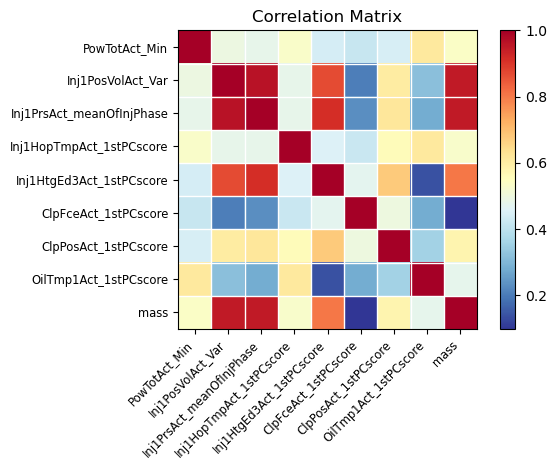

In [233]:
# plot the correlation matrix
plot_corr(normalized_corr_matrix,xnames=training_data.columns)
plt.show()

In [250]:
# Calculate Variance Inflation (VIP) Table
# book S.124
vals = [variance_inflation_factor(X_all_train, i) for i in range(1, X_all_train.shape[1])]
vif = pd.DataFrame({'vif':vals},
index=X_all_train.columns[1:])
vif

,vif
PowTotAct_Min,1.070054
Inj1PosVolAct_Var,8.895456
Inj1PrsAct_meanOfInjPhase,24.367715
Inj1HopTmpAct_1stPCscore,1.104856
Inj1HtgEd3Act_1stPCscore,12.039412
ClpFceAct_1stPCscore,15.257238
ClpPosAct_1stPCscore,1.303963
OilTmp1Act_1stPCscore,7.524084


### Whats our model accuracy?
On average the model makes an error of `1.1629E-2 mass units` `(RSE=0.011629714918419206)`.
Since the average mass is `33.058716 mass units`, that suggests an on average error 
of about `RSE/y_avg= 3.5179%` which could not be that bad.
Sadly the unit of mass is not given, which makes assessing this error harder.

The R-Squared value is `0.987`, which suggest a large proportion of variability
in mass can be explained when using all the predictors.
This suggests that the assumption of a linear relationship is correct.

### Is there a relationship between any of the predictors and the output?
The F-Statistics value is `1312` and the p-value is `2.55e-128`.
Here the p-value can be interpreted as the probability that the null hypothesis is true (i.e., that all of the regression coefficients are zero).
Since it is very close to zero, the probability is very low, therefore we reject the hypothesis.

### Are there correlations between predictors?
#### T-Test
High P-Values in the T-Test:
```
PowTotAct_Min               = 0.431
Inj1HopTmpAct_1stPCscore    = 0.758
ClpPosAct_1stPCscore        = 0.247
```
#### Correlation Matrix with >0.9
```
                   Variable 1                 Variable 2  Correlation
8           Inj1PosVolAct_Var  Inj1PrsAct_meanOfInjPhase     0.962592
16  Inj1PrsAct_meanOfInjPhase   Inj1HtgEd3Act_1stPCscore     0.912535
```
#### Variance Inflation Factor (VIF)
In the VIF the value the minimum value is 1, which suggests complete lack of colliniearity.
The lecture material on linear regression suggests on slide 83 to use the boundary 5 as a rule of thumb.
Therefore we can identify the following predictors:
```
Inj1PosVolAct_Var	        = 8.895456
Inj1PrsAct_meanOfInjPhase	= 24.367715
Inj1HtgEd3Act_1stPCscore	= 12.039412
ClpFceAct_1stPCscore	        = 15.257238
OilTmp1Act_1stPCscore	        = 7.524084
```

## Model Comparison using one predictor

In [52]:
Y_single_pred = training_data["mass"]
for col_name in training_data:
    if col_name == 'mass':
        continue

    x_single_pred_train = training_data[col_name]
    x_single_pred_train = sm.add_constant(x_single_pred_train)
    model_single_predictor = sm.OLS(Y_single_pred, x_single_pred_train)

    results_single_predictor = model_single_predictor.fit()
    rse_single_predictor = np.sqrt(results_single_predictor.mse_resid)
    
    print(f'{col_name}: \n RSE={rse_single_predictor} R_squared={results_single_predictor.rsquared} p-val:{results_single_predictor.pvalues}')

PowTotAct_Min: 
 RSE=0.09835457494845118 R_squared=0.005096422119708399 p-val:const            0.000000
PowTotAct_Min    0.385323
dtype: float64
Inj1PosVolAct_Var: 
 RSE=0.04404387342931999 R_squared=0.8004908249890692 p-val:const                1.865029e-90
Inj1PosVolAct_Var    1.150618e-53
dtype: float64
Inj1PrsAct_meanOfInjPhase: 
 RSE=0.04299826217856696 R_squared=0.8098511654735838 p-val:const                        3.317511e-259
Inj1PrsAct_meanOfInjPhase     3.266835e-55
dtype: float64
Inj1HopTmpAct_1stPCscore: 
 RSE=0.09843667772284106 R_squared=0.0034347111606157776 p-val:const                       4.627896e-108
Inj1HopTmpAct_1stPCscore     4.762251e-01
dtype: float64
Inj1HtgEd3Act_1stPCscore: 
 RSE=0.078218716762003 R_squared=0.37076447406316015 p-val:const                       0.000000e+00
Inj1HtgEd3Act_1stPCscore    1.376962e-16
dtype: float64
ClpFceAct_1stPCscore: 
 RSE=0.05863737622585755 R_squared=0.6463766619331461 p-val:const                   0.000000e+00
ClpFceAct_1

## Model Selection (Exhaustive Search)

Best predictors: ('PowTotAct_Min', 'Inj1PosVolAct_Var', 'Inj1PrsAct_meanOfInjPhase', 'Inj1HopTmpAct_1stPCscore', 'Inj1HtgEd3Act_1stPCscore', 'ClpFceAct_1stPCscore', 'ClpPosAct_1stPCscore', 'OilTmp1Act_1stPCscore')
Removed columns for 8 predictors: set()
----------------------------------------------------------
Best predictors: ('PowTotAct_Min', 'Inj1PosVolAct_Var', 'Inj1PrsAct_meanOfInjPhase', 'Inj1HtgEd3Act_1stPCscore', 'ClpFceAct_1stPCscore', 'ClpPosAct_1stPCscore', 'OilTmp1Act_1stPCscore')
Removed columns for 7 predictors: {'PowTotAct_Min'}
----------------------------------------------------------
Best predictors: ('Inj1PosVolAct_Var', 'Inj1PrsAct_meanOfInjPhase', 'Inj1HtgEd3Act_1stPCscore', 'ClpFceAct_1stPCscore', 'ClpPosAct_1stPCscore', 'OilTmp1Act_1stPCscore')
Removed columns for 6 predictors: {'Inj1PosVolAct_Var', 'PowTotAct_Min'}
----------------------------------------------------------
Best predictors: ('Inj1PosVolAct_Var', 'Inj1PrsAct_meanOfInjPhase', 'Inj1HtgEd3Act_1stPCs

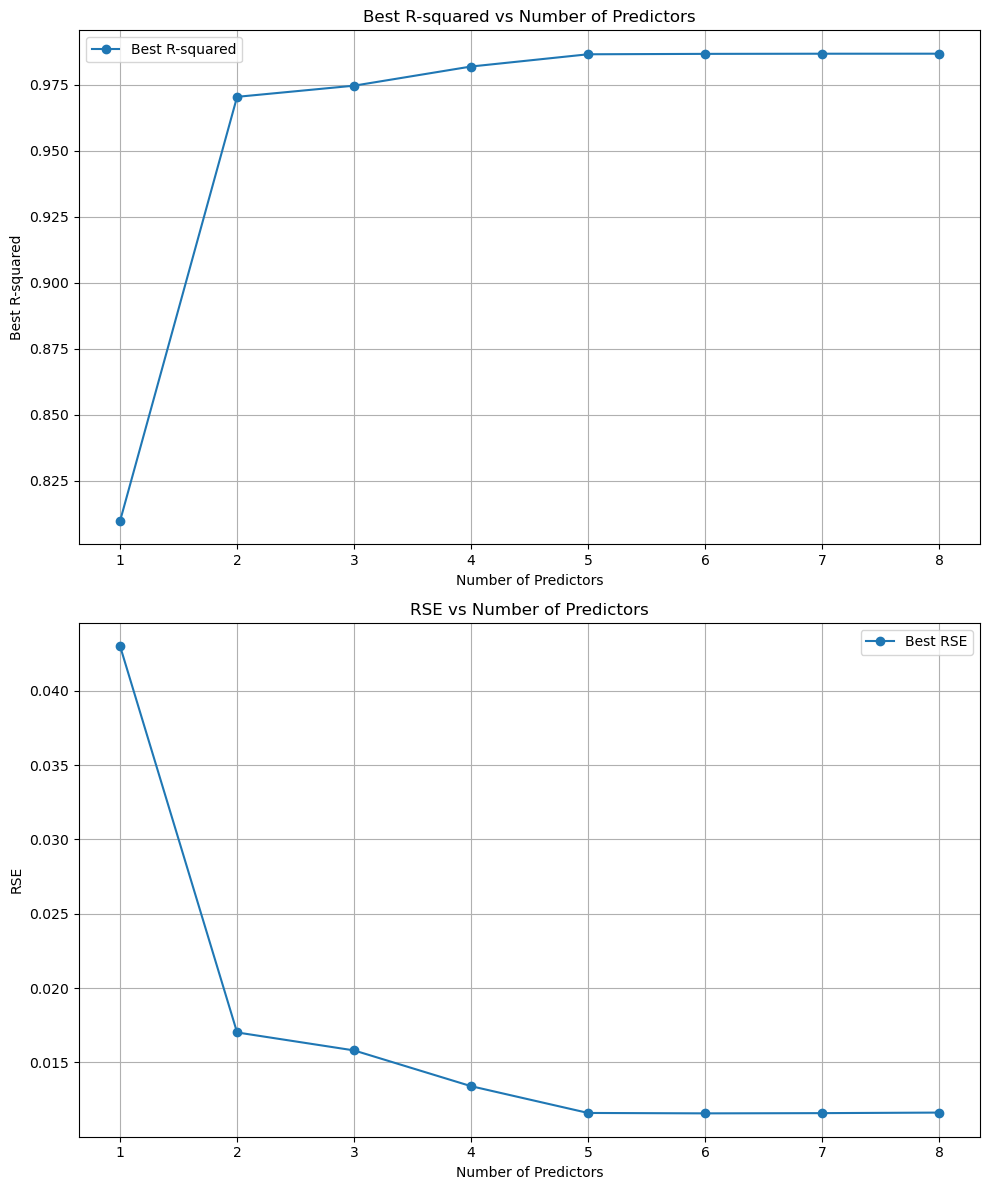

In [238]:
from itertools import combinations

Y_search_train = training_data["mass"]
X_search_train = training_data.drop("mass", axis=1)

# Function to calculate R-squared and RSE for a given set of predictors
def evaluate_model(predictors, x, y):
    X_subset = x[list(predictors)]
    X_subset = sm.add_constant(X_subset)
    model_subset = sm.OLS(y, X_subset)
    results_subset = model_subset.fit()
    r_squared_subset = results_subset.rsquared
    rse_subset = np.sqrt(results_subset.mse_resid)
    return r_squared_subset, rse_subset

def exhaustive_search(number_of_predictors):
    # Initialize variables to store the best model
    best_r_squared = -np.inf
    best_rse = np.inf
    best_predictors = None

    # Define the maximum number of sensors allowed
    max_sensors = number_of_predictors

    # Iterate over all possible combinations of predictors within the sensor limit
    for k in range(1, max_sensors + 1):
        for subset in combinations(X_search_train.columns, k):
            r_squared, rse = evaluate_model(subset, X_search_train, Y_search_train)
            if r_squared > best_r_squared or (r_squared == best_r_squared and rse < best_rse): #if r_squared same compare rse
                best_r_squared = r_squared
                best_rse = rse
                best_predictors = subset
    #print(f'number of predictors: {max_sensors}')
    print(f'Best predictors: {best_predictors}')
    #print(f'Best R-squared: {best_r_squared}')
    #print(f'Best RSE: {best_rse}')
    return list(subset), best_r_squared, best_rse

results_list = []

for i in reversed(range(1, 9)):
    subset_list, best_rsquared, best_rse = exhaustive_search(i)
    removed_columns = set(X_search_train.columns) - set(subset_list)
    results_list.append((i, best_rsquared, best_rse))
    print(f'Removed columns for {i} predictors: {removed_columns}')
    print("----------------------------------------------------------")

# Create a pandas DataFrame with the results
results_df = pd.DataFrame(results_list, columns=['Number of Predictors', 'Best R-squared', 'Best RSE'])

# Plot the results
fig, ax = plt.subplots(2, 1, figsize=(10, 12))

print(results_df)
# Plot R-squared
ax[0].plot(results_df['Number of Predictors'], results_df['Best R-squared'], marker='o', label='Best R-squared')
ax[0].set_xlabel('Number of Predictors')
ax[0].set_ylabel('Best R-squared')
ax[0].set_title('Best R-squared vs Number of Predictors')
ax[0].legend()
ax[0].grid(True)

# Plot RSE
ax[1].plot(results_df['Number of Predictors'], results_df['Best RSE'], marker='o', label='Best RSE')
ax[1].set_xlabel('Number of Predictors')
ax[1].set_ylabel('RSE')
ax[1].set_title('RSE vs Number of Predictors')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()




# Economical Model Test Data Prediction
This is the model as described in the answer of question 3 which uses the least amount of sensors without restricting the model performance too much.

In [53]:
X_economical_train = training_data[["Inj1HtgEd3Act_1stPCscore", "ClpFceAct_1stPCscore"]]
Y_economical_train = training_data["mass"]

X_economical_train = sm.add_constant(X_economical_train)
model_economical = sm.OLS(Y_economical_train, X_economical_train)
results_economical = model_economical.fit()

mse_economical_train = results_economical.mse_resid
rse_economical_train = np.sqrt(mse_economical_train)
rsquared_economical_train = results_economical.rsquared

print(f'MSE:{mse_economical_train} RSE{rse_economical_train} rsquared:{rsquared_economical_train}')
print(results_economical.summary())

MSE:0.0002896525237734084 RSE0.017019181054722003 rsquared:0.9704113740814461
                            OLS Regression Results                            
Dep. Variable:                   mass   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     2411.
Date:                Sun, 27 Oct 2024   Prob (F-statistic):          4.24e-113
Time:                        11:14:49   Log-Likelihood:                 399.69
No. Observations:                 150   AIC:                            -793.4
Df Residuals:                     147   BIC:                            -784.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

In [34]:
# test
X_economical_test = test_data[["Inj1HtgEd3Act_1stPCscore", "ClpFceAct_1stPCscore"]]
X_economical_test = sm.add_constant(X_economical_test)  # Add constant (intercept)
Y_economical_test = test_data["mass"]

# predict based on fit train model
test_predictions = results_economical.predict(X_economical_test)
# calculate mse and rse
mse_economical_test = np.mean((test_predictions - Y_economical_test) ** 2)
rse_economical_test = np.sqrt(mse_economical_test)

# r_squared
ss_total = np.sum((Y_economical_test - np.mean(Y_economical_test)) ** 2)
ss_residual = np.sum((Y_economical_test - test_predictions) ** 2)
rsquared_economical_test = 1 - (ss_residual / ss_total)

print(f'MSE Test:{mse_economical_test} MSE Train:{mse_economical_train} diff:{mse_economical_test-mse_economical_train}')
print(f'RSE Test:{rse_economical_test} RSE Train:{rse_economical_train} diff:{rse_economical_test - rse_economical_train}')
print(f'rsquared test:{rsquared_economical_test} rsquared train:{rsquared_economical_train} diff{rsquared_economical_train-rsquared_economical_test}')

MSE Test:0.0004966225822075184 MSE Train:0.0002896525237734084 diff:0.00020697005843411
RSE Test:0.022285030451123875 RSE Train:0.017019181054722003 diff:0.005265849396401873
rsquared test:0.9430288106655366 rsquared train:0.9704113740814461 diff0.0273825634159095


## Model Selection (Interaction and Higher Order Terms)
We will start of be using our economical model with only two predictors.

In [38]:
# training data
X_economical_ho_train = training_data[["Inj1HtgEd3Act_1stPCscore", "ClpFceAct_1stPCscore"]].copy()
# interaction predictor
X_economical_ho_train["Inj1HtgEd3Act_1stPCscore*ClpFceAct_1stPCscore"] = X_economical_ho_train["Inj1HtgEd3Act_1stPCscore"] * X_economical_ho_train["ClpFceAct_1stPCscore"]

X_economical_ho_train= sm.add_constant(X_economical_ho_train)
Y_economical_ho_train = training_data["mass"]

# fit to model
model_economical_ho = sm.OLS(Y_economical_ho_train, X_economical_ho_train)
results_economical_ho = model_economical_ho.fit()

# save mse and rese
mse_economical_ho_train = results_economical_ho.mse_resid
rse_economical_ho_train = np.sqrt(mse_economical_ho_train)
rsquared_economical_ho_train = results_economical_ho.rsquared


print(f'MSE:{mse_economical_ho_train} RSE:{rse_economical_ho_train} rsquared:{rsquared_economical_ho_train}')

MSE:0.0002680822154144665 RSE:0.016373216404068764 rsquared:0.9728011209891272


In [62]:
results_economical_ho.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   mass   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     1741.
Date:                Sun, 27 Oct 2024   Prob (F-statistic):          5.04e-114
Time:                        12:08:09   Log-Likelihood:                 406.00
No. Observations:                 150   AIC:                            -804.0
Df Residuals:                     146   BIC:                            -792.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=================================================================================================================
                                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
const                                            33.2099      0.003   1.01e+04      0.000      33.203      33.216
Inj1HtgEd3Act_1stPCscore                          0.0009   2.72e-05     32.038      0.000       0.001       0.001
ClpFceAct_1stPCscore                             -0.0010    4.9e-05    -20.901      0.000      -0.001      -0.001
Inj1HtgEd3Act_1stPCscore*ClpFceAct_1stPCscore  -1.73e-06   4.83e-07     -3.582      0.000   -2.68e-06   -7.75e-07
==============================================================================
Omnibus:                       10.610   Durbin-Watson:                   1.878
Prob(Omnibus):                  0.005   Jarque-Bera (JB):               24.245
Skew:                           0.134   Prob(JB):                     5.43e-06
Kurtosis:                       4.951   Cond. No.                     2.85e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.85e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [43]:
# test data
X_economical_ho_test = test_data[["Inj1HtgEd3Act_1stPCscore", "ClpFceAct_1stPCscore"]].copy()
X_economical_ho_test["Inj1HtgEd3Act_1stPCscore*ClpFceAct_1stPCscore"] = X_economical_ho_test["Inj1HtgEd3Act_1stPCscore"] * X_economical_ho_test["ClpFceAct_1stPCscore"]
X_economical_ho_test = sm.add_constant(X_economical_ho_test)

Y_economical_ho_test = test_data["mass"]

# predict using fitted model
test_ho_predictions = results_economical_ho.predict(X_economical_ho_test)

# calc mse and rse
mse_economical_ho_test = np.mean((test_ho_predictions - Y_economical_ho_test) ** 2)
rse_economical_ho_test = np.sqrt(mse_economical_ho_test)

# r_squared
ss_ho_total = np.sum((Y_economical_ho_test - np.mean(Y_economical_ho_test)) ** 2)
ss_ho_residual = np.sum((Y_economical_ho_test - test_ho_predictions) ** 2)
rsquared_economical_ho_test = 1 - (ss_ho_residual / ss_ho_total)

# print results
print(f'MSE Test:{mse_economical_ho_test} MSE Train:{mse_economical_ho_train} diff:{mse_economical_ho_test-mse_economical_ho_train}')
print(f'RSE Test:{rse_economical_ho_test} RSE Train:{rse_economical_ho_train} diff:{rse_economical_ho_test - rse_economical_ho_train}')
print(f'rsquared test:{rsquared_economical_ho_test} rsquared train:{rsquared_economical_ho_train} diff{rsquared_economical_ho_train-rsquared_economical_ho_test}')

MSE Test:0.0004718341690072129 MSE Train:0.0002680822154144665 diff:0.00020375195359274644
RSE Test:0.021721744152052178 RSE Train:0.016373216404068764 diff:0.0053485277479834135
rsquared test:0.9458724698794573 rsquared train:0.9728011209891272 diff0.02692865110966991


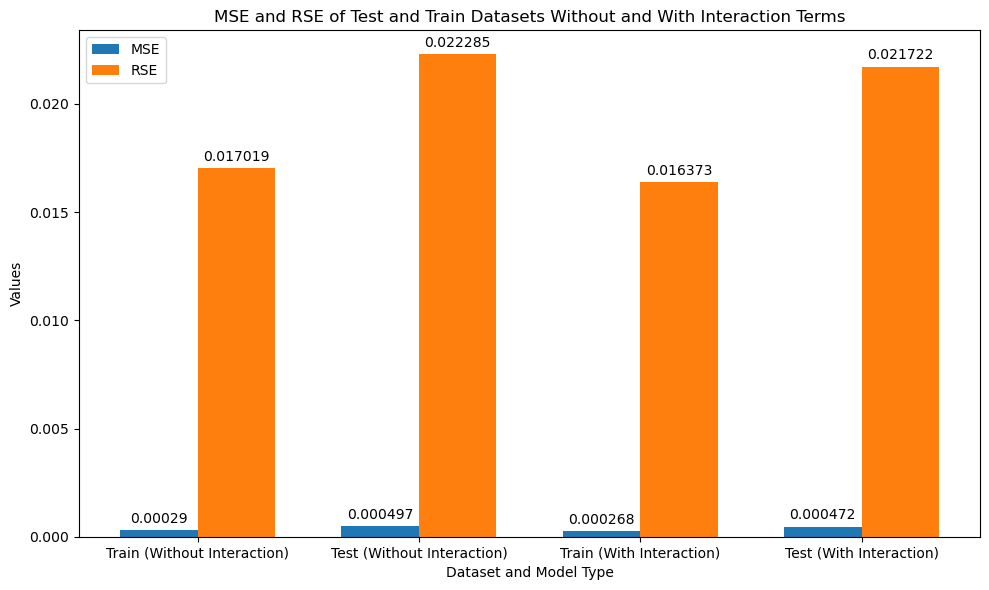

In [45]:
# Data for the bar chart
labels = ['Train (Without Interaction)', 'Test (Without Interaction)', 'Train (With Interaction)', 'Test (With Interaction)']
mse_values = [mse_economical_train, mse_economical_test, mse_economical_ho_train, mse_economical_ho_test]
rse_values = [rse_economical_train, rse_economical_test, rse_economical_ho_train, rse_economical_ho_test]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plotting MSE values
rects1 = ax.bar(x - width/2, mse_values, width, label='MSE')

# Plotting RSE values
rects2 = ax.bar(x + width/2, rse_values, width, label='RSE')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Dataset and Model Type')
ax.set_ylabel('Values')
ax.set_title('MSE and RSE of Test and Train Datasets Without and With Interaction Terms')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Function to add labels on the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 6)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

plt.show()

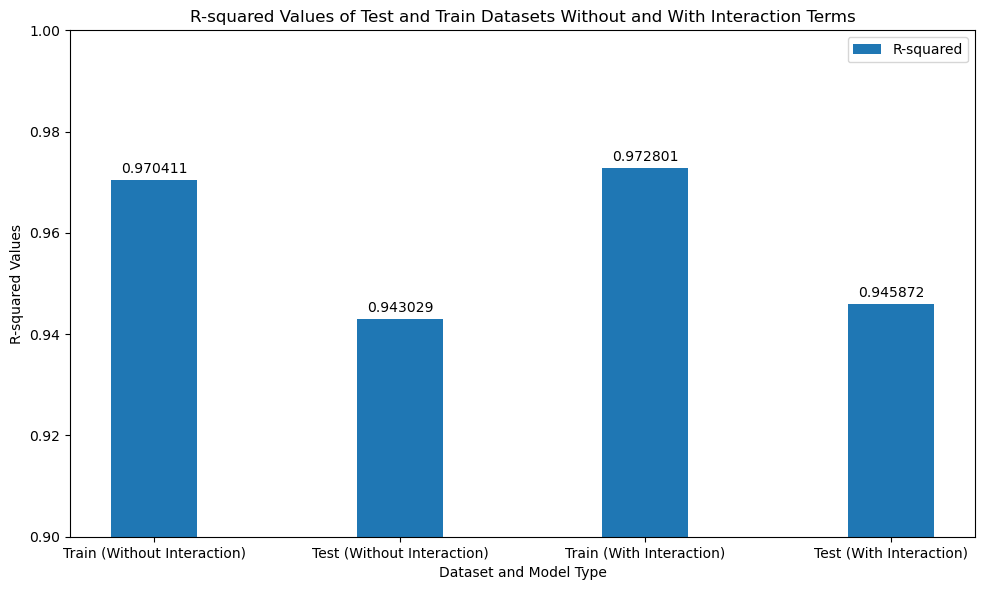

In [54]:
# Data for the bar chart
labels = ['Train (Without Interaction)', 'Test (Without Interaction)', 'Train (With Interaction)', 'Test (With Interaction)']
rsquared_values = [rsquared_economical_train, rsquared_economical_test, rsquared_economical_ho_train, rsquared_economical_ho_test]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plotting R-squared values
rects = ax.bar(x, rsquared_values, width, label='R-squared')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Dataset and Model Type')
ax.set_ylabel('R-squared Values')
ax.set_title('R-squared Values of Test and Train Datasets Without and With Interaction Terms')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Set y-axis limits
ax.set_ylim(0.9, 1)

# Function to add labels on the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 6)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects)

fig.tight_layout()

plt.show()

### Residuals as a function of the predicted response

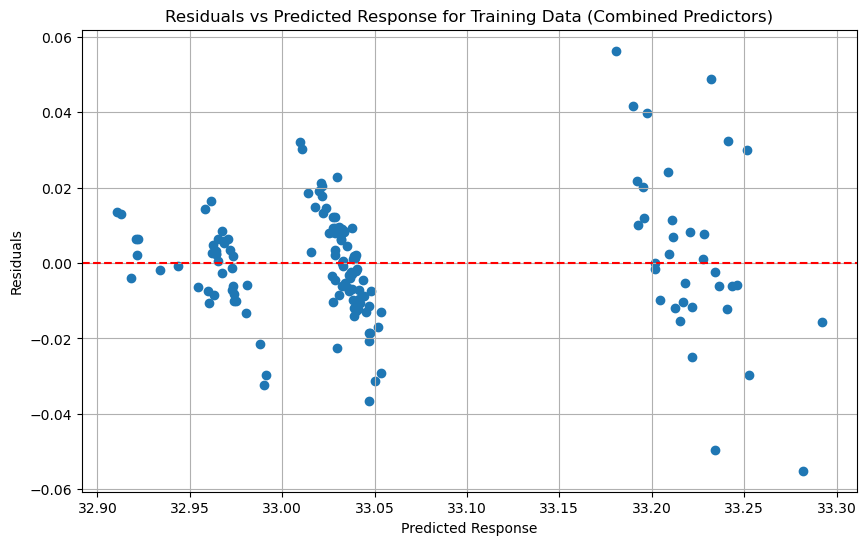

In [50]:
# Calculate residuals for training data
train_ho_predictions = results_economical_ho.predict(X_economical_ho_train)
train_residuals = Y_economical_ho_train - train_ho_predictions

# Plot residuals vs predicted response for training data
plt.figure(figsize=(10, 6))
plt.scatter(train_ho_predictions, train_residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Response')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Response for Training Data (Combined Predictors)')
plt.grid(True)
plt.show()

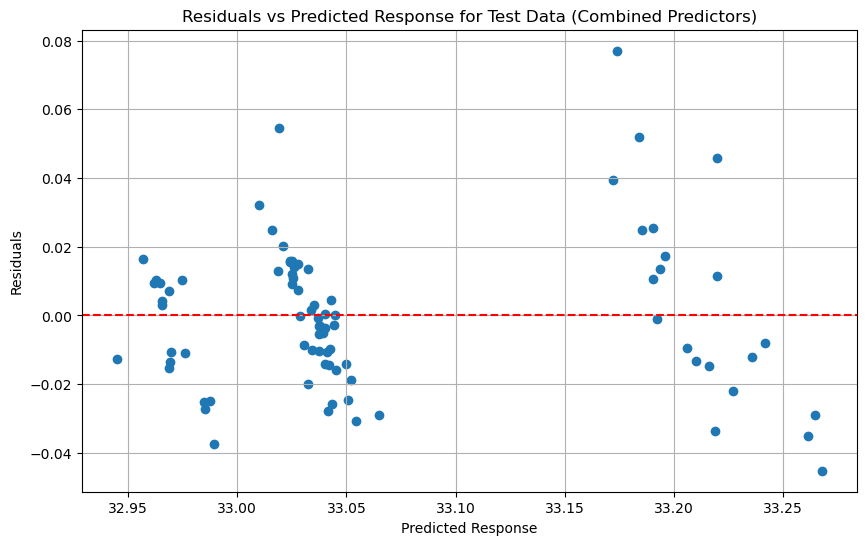

In [48]:
# Calculate residuals
residuals = Y_economical_ho_test - test_ho_predictions

# Plot residuals vs predicted response
plt.figure(figsize=(10, 6))
plt.scatter(test_ho_predictions, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Response')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Response for Test Data (Combined Predictors)')
plt.grid(True)
plt.show()

Log()

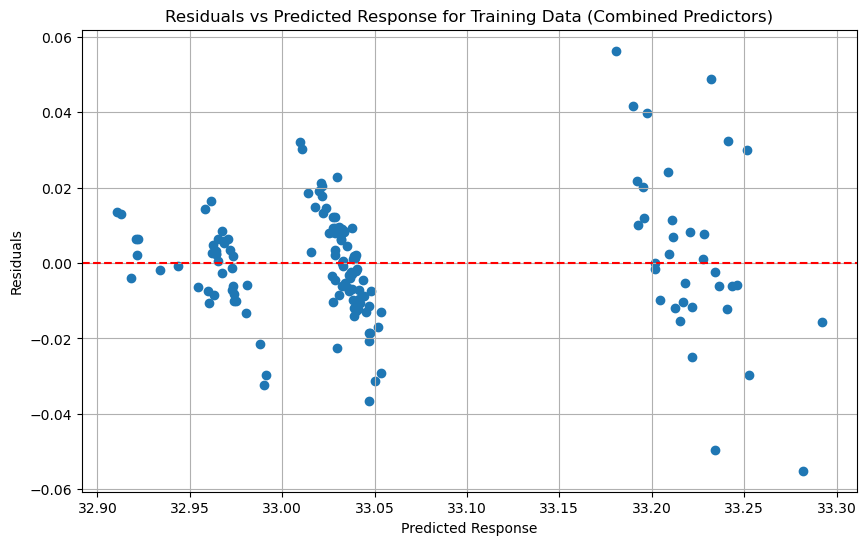

In [61]:
train_ho_predictions = results_economical_ho.predict(X_economical_ho_train)
train_ho_predictions = train_ho_predictions
train_residuals = Y_economical_ho_train - train_ho_predictions

# Plot residuals vs predicted response for training data
plt.figure(figsize=(10, 6))
plt.scatter(train_ho_predictions, train_residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Response')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Response for Training Data (Combined Predictors)')
plt.grid(True)
plt.show()